# Show5DSTEM — All Features

Comprehensive demo of 5D-STEM workflows: `IO.arina_folder()` → `Show4DSTEM` with frame slider,
virtual imaging across time, and programmatic frame comparison.

In [1]:
try:
    %load_ext autoreload
    %autoreload 2
    %env ANYWIDGET_HMR=1
except Exception:
    pass

env: ANYWIDGET_HMR=1


In [2]:
import numpy as np
from quantem.widget import Show4DSTEM, Show2D
from quantem.widget.io import IOResult

## Setup: synthetic 5D-STEM time series

Simulate 8 sequential 4D-STEM scans with evolving strain (Bragg spot shifts)
and dose-dependent amorphization.

In [3]:
rng = np.random.default_rng(42)
n_frames = 8
scan_r, scan_c = 32, 32
det_r, det_c = 48, 48
center = (det_r // 2, det_c // 2)
dr, dc = np.mgrid[:det_r, :det_c]
sr, sc_grid = np.mgrid[:scan_r, :scan_c]
data_5d = np.zeros((n_frames, scan_r, scan_c, det_r, det_c), dtype=np.float32)
g_vectors = [(8, 0), (-8, 0), (0, 8), (0, -8), (6, 6), (-6, -6), (6, -6), (-6, 6)]
for t in range(n_frames):
    strain = 0.15 * t / n_frames
    amorphization = 0.3 * t / n_frames
    shift_r = strain * np.sin(2 * np.pi * sr / scan_r)[:, :, None, None]
    shift_c = strain * np.cos(2 * np.pi * sc_grid / scan_c)[:, :, None, None]
    beam = np.exp(-((dr - center[0])**2 + (dc - center[1])**2) / (2 * 3.5**2))
    pattern = beam.copy()
    for gr, gc in g_vectors:
        spot_intensity = max(0.05, 0.35 * (1 - amorphization))
        pattern += spot_intensity * np.exp(-((dr - center[0] - gr)**2 + (dc - center[1] - gc)**2) / (2 * 1.5**2))
    thickness = (1.0 + 0.4 * sr / scan_r)[:, :, None, None]
    frame = pattern[None, None, :, :] * thickness
    data_5d[t] = frame + rng.poisson(0.3, (scan_r, scan_c, det_r, det_c)).astype(np.float32)
labels = [f"scan_{i:03d}" for i in range(n_frames)]
result = IOResult(data=data_5d, title="StrainEvolution", labels=labels)
print(result)

IOResult
  shape:      8 x 32 x 32 x 48 x 48
  dtype:      float32
  title:      StrainEvolution
  labels:     ['scan_000', 'scan_001', 'scan_002', ...] (8 total)


## 5D viewer with time slider

Show4DSTEM auto-detects the leading frame dimension and adds playback controls.

In [4]:
w = Show4DSTEM(result, frame_dim_label="Time")
w.summary()
w

StrainEvolution
════════════════════════════════
Frames:   8 (Time), current: 0 | 5.0 fps | loop
Labels:   ['scan_000', 'scan_001', 'scan_002'] ... (8 total)
Scan:     32×32 (1.00 Å/px)
Detector: 48×48 (1.0000 px/px)
Position: (16, 16)
Center:   (24.0, 24.0)  BF r=8.7 px
Display:  DC masked
ROI:      point at (24.0, 24.0) r=4.4
DP view:  inferno, linear, 0.0-100.0%
VI view:  inferno, linear, 0.0-100.0%


Show4DSTEM(shape=(8, 32, 32, 48, 48), sampling=(1.0 Å, 1.0 px), pos=(16, 16), time=0, title='StrainEvolution')

## Virtual bright-field across time

Compute virtual BF image for each frame to track dose-dependent contrast changes.

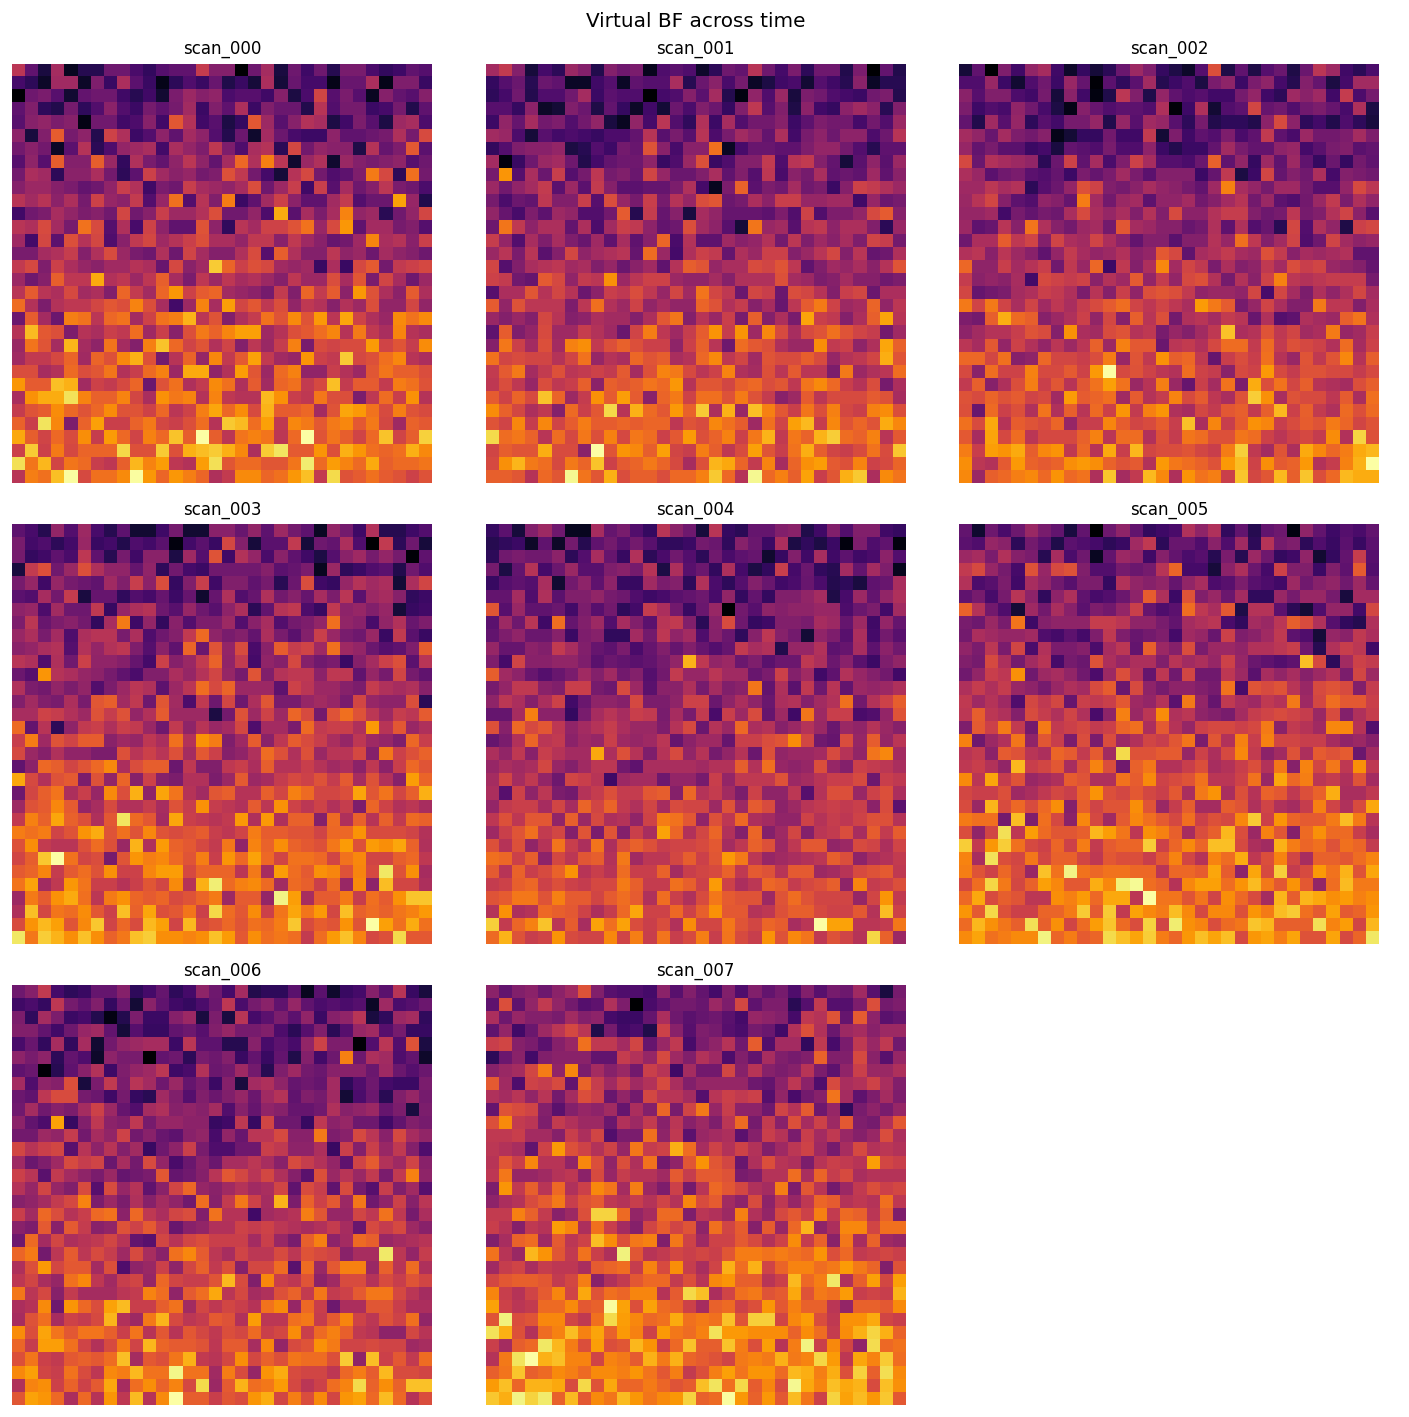

In [5]:
bf_radius = 5
mask = ((dr - center[0])**2 + (dc - center[1])**2) < bf_radius**2
vbf_stack = np.zeros((n_frames, scan_r, scan_c), dtype=np.float32)
for t in range(n_frames):
    vbf_stack[t] = (data_5d[t] * mask[None, None, :, :]).sum(axis=(-2, -1))
Show2D(vbf_stack, title="Virtual BF across time", labels=labels)

## Mean diffraction pattern per frame

Average all scan positions per frame to see Bragg spot intensity evolution.

Mean DP stack: (8, 48, 48)


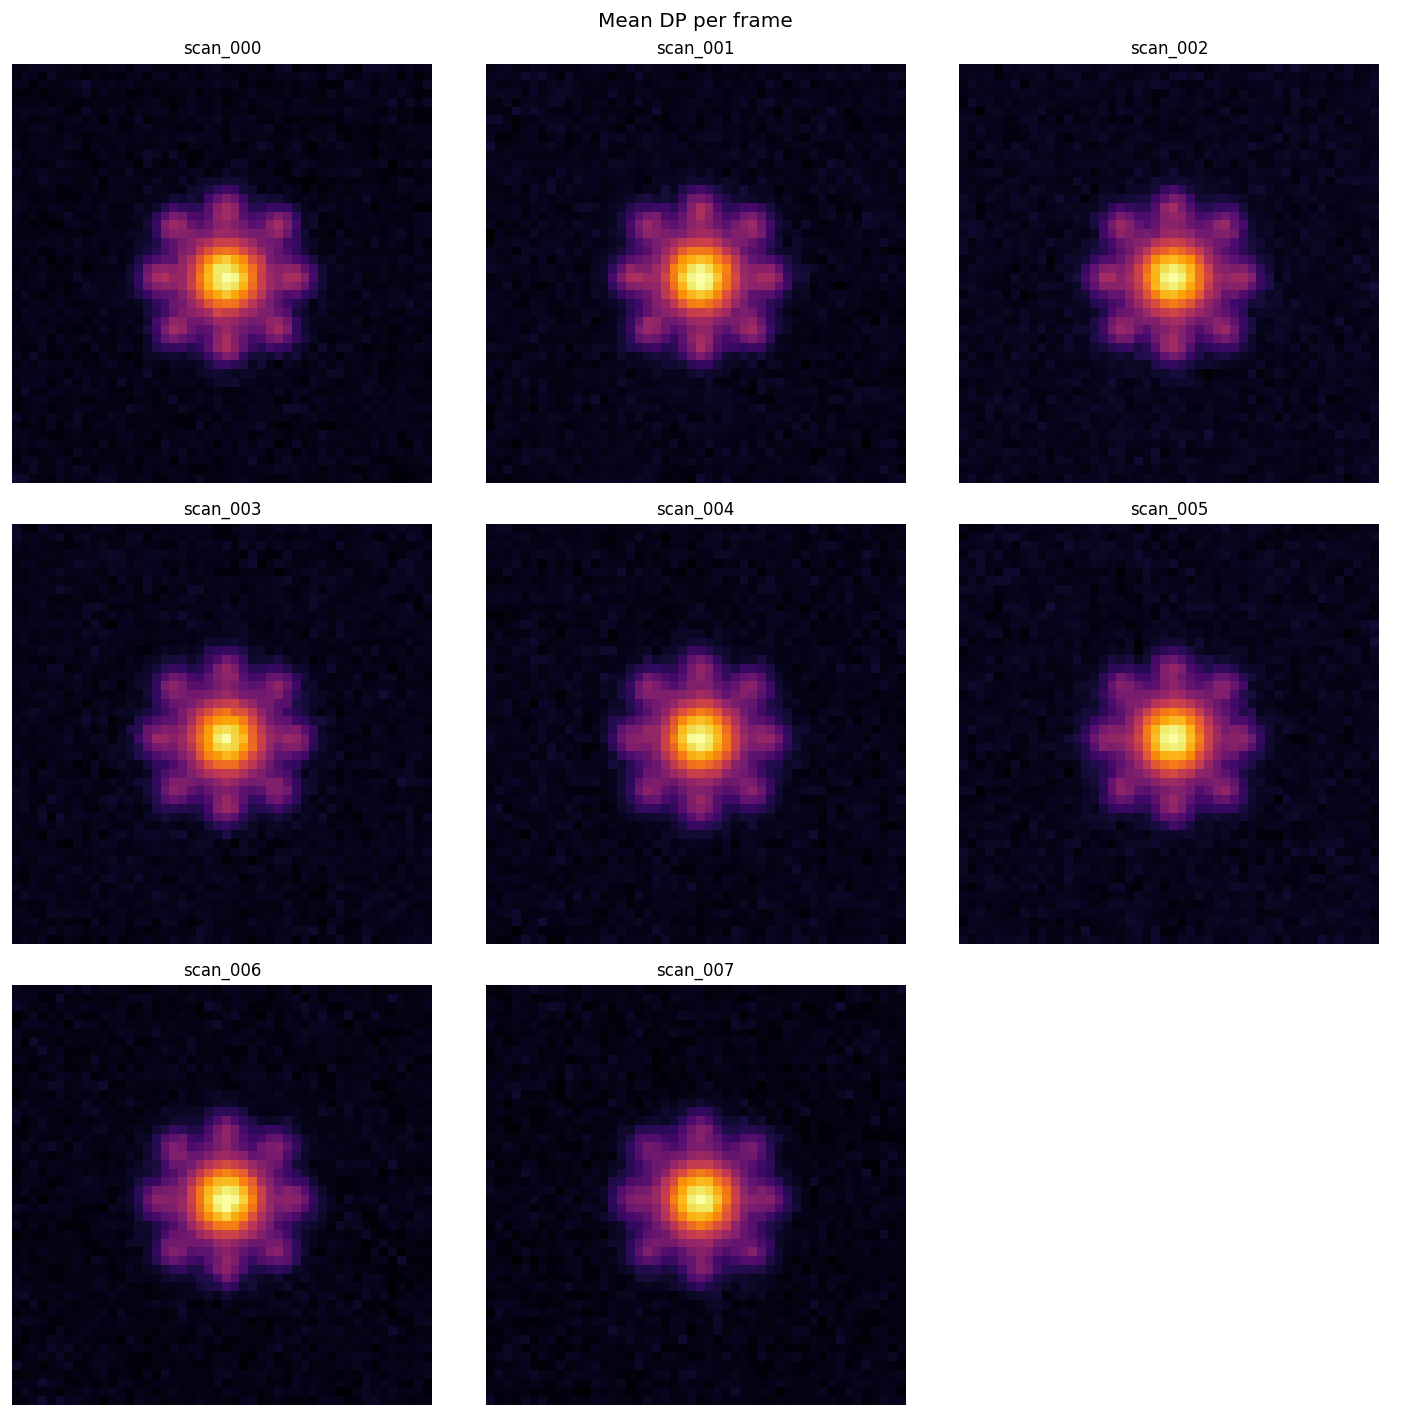

In [6]:
mean_dp_stack = data_5d.mean(axis=(1, 2))
print(f"Mean DP stack: {mean_dp_stack.shape}")
Show2D(mean_dp_stack, title="Mean DP per frame", labels=labels, log_scale=True)

## Frame comparison: first vs last

Compare diffraction at the same scan position across the first and last frame.

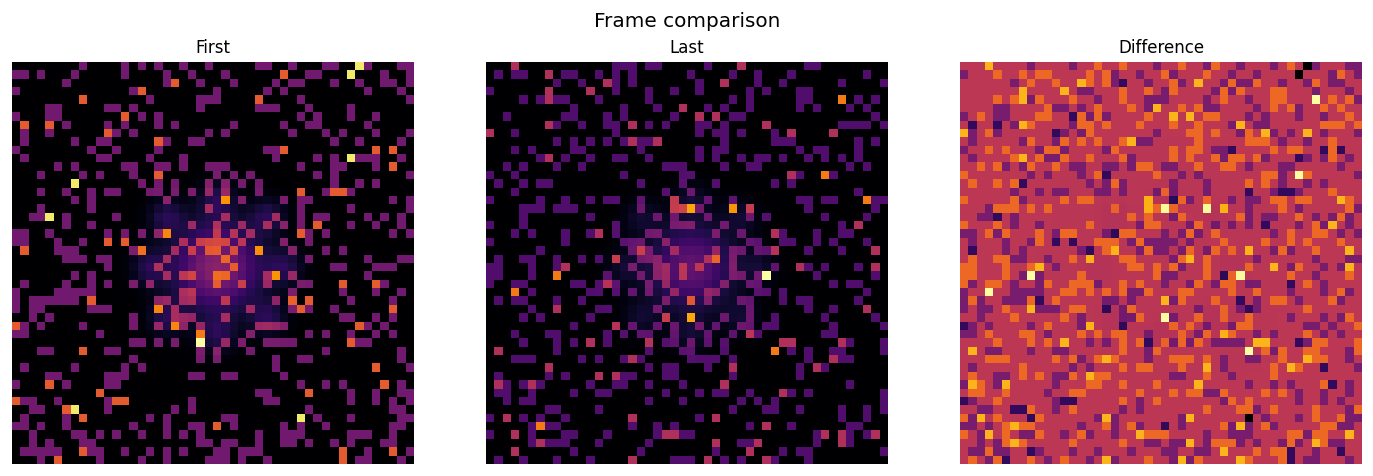

In [7]:
pos = (scan_r // 2, scan_c // 2)
dp_first = data_5d[0, pos[0], pos[1]]
dp_last = data_5d[-1, pos[0], pos[1]]
diff = dp_last - dp_first
comparison = np.stack([dp_first, dp_last, diff])
Show2D(comparison, title="Frame comparison", labels=["First", "Last", "Difference"])

## Real data workflow

With real arina data, the workflow is:

```python
from quantem.widget import IO, Show4DSTEM

# Load all scans in a session folder → 5D
result = IO.arina_folder("/path/to/session/", det_bin=4)
# result.data.shape = (10, 256, 256, 48, 48)
# result.labels = ['scan_00', 'scan_01', ...]

# View with time slider
Show4DSTEM(result, frame_dim_label="Scan")
```